# Generalized Integrate-and-Fire Neuron

In [1]:
#!pip install ANNarchy

This notebook explores the generalized Integrate-and-Fire neuron model being used in CUBA-like network. This network has been proposed in

> Brette, R., Rudolph, M., Carnevale, T., Hines, M., Beeman, D., Bower, J. M., et al. (2007), Simulation of networks of spiking neurons: a review of tools and strategies., *J. Comput. Neurosci., 23, 3, 349–98*

as benchmark and is based on:

> Vogels, T. P. and Abbott, L. F. (2005), Signal propagation and logic gating in networks of integrate-and-fire neurons., *J. Neurosci., 25, 46, 10786–95*

However, in this notebook, we don't use a standard LIF model, but the generalized IaF neuron described in:

> Schwalger, T., Deger, M., Gerstner, w. (2017). Towards a theory of cortical columns: From spiking neurons to interacting neural populations of finite size. PLoS Comput Biol. 2017;13(4):e1005507


In [2]:
import matplotlib.pyplot as plt
import numpy

import ANNarchy as ann

ANNarchy 5.0 (5.0.2) on linux (posix).


The generalized leaky Integrate-and-Fire neuron is defined by the following equations:

$$
    \tau_m \frac{du}{dt} = -u + u_r + R*(I_{ext} + I_{exc} + I_{inh})
$$

$$
    \tau_v \frac{dv}{dt} = -(v-u_{th})
$$

Spike emission is the result of a stochastic process, where the threshold $\lambda$, also called hazard-rate, follows the difference between the membrane potential $u$ and an adaptive threshold $v$:

$$
    \lambda = c * exp(\frac{u-v}{\delta_{u}})
$$

In the following we construct a CUBA like network, inspired by the work of Vogels and Abbott (2005). Adapted the parameters of the GIF neuron model to obtain comparable statistics. The GIF model with currents is part of the default models in ANNarchy.

In [3]:
class CUBANetwork (ann.Network):
    
    def __init__(self, w_exc, w_inh):

        self.P = self.create(geometry=4000, neuron=ann.GIF_curr_exp)

        self.P[:3200].Jv = 1500 # mv/ms
        self.P[3200:].Jv = 0    # mv/ms, no adaptation for inhibitory cells
        
        self.Ce = self.connect(pre=self.P[:3200], post=self.P, target='exc')
        self.Ce.fixed_probability(weights=w_exc, probability=0.02)

        self.Ci = self.connect(pre=self.P[3200:], post=self.P, target='inh')
        self.Ci.fixed_probability(weights=w_inh, probability=0.02)

        self.m = self.monitor(self.P, ['spike'])

In [4]:
# CUBA network
we_CUBA = 1.62
wi_CUBA = 9.0

net_cuba = CUBANetwork(w_exc=we_CUBA, w_inh=wi_CUBA, dt=0.1)
net_cuba.compile()


Compiling network 1... 

OK


In [5]:
net_cuba.simulate(1000., measure_time=True)

Simulating 1.0 seconds of the network 1 took 0.9236607551574707 seconds.


In [6]:
data_CUBA = net_cuba.m.get('spike')

In [7]:
t_CUBA, n_CUBA = net_cuba.m.raster_plot(data_CUBA)

In [8]:
print('Mean firing rate in the COBA population: ' + str(len(t_CUBA) / 4000.) + 'Hz')

Mean firing rate in the COBA population: 5.82225Hz


Text(0, 0.5, '# neuron')

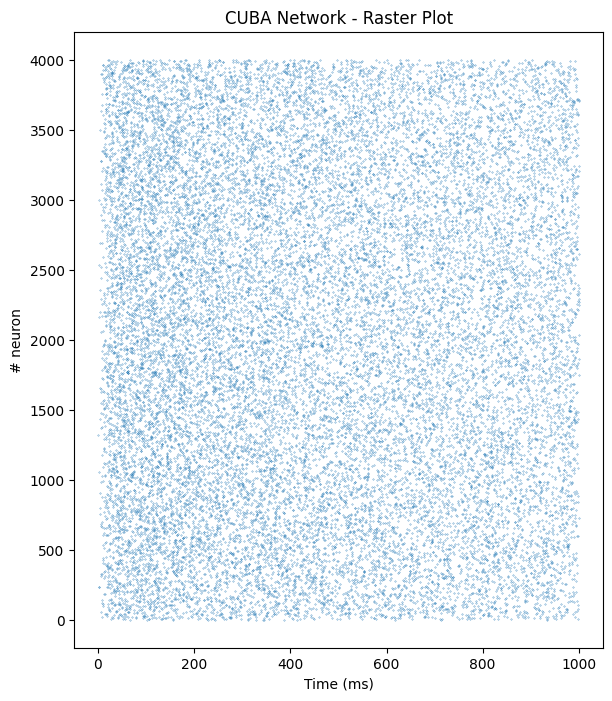

In [9]:
plt.figure(figsize=(15, 8))
plt.subplot(121)
plt.title("CUBA Network - Raster Plot")
plt.plot(t_CUBA, n_CUBA, '.', markersize=0.5)
plt.xlabel('Time (ms)')
plt.ylabel('# neuron')

In [10]:
isi_CUBA = net_cuba.m.inter_spike_interval(data_CUBA)

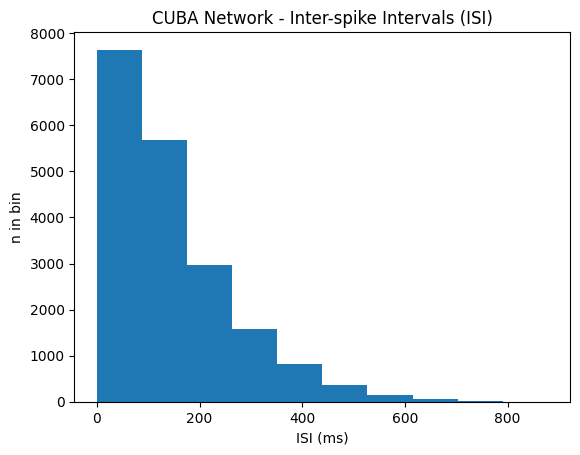

In [11]:
plt.title("CUBA Network - Inter-spike Intervals (ISI)")
plt.hist(isi_CUBA)
plt.xlabel('ISI (ms)')
plt.ylabel('n in bin')
plt.show()

In [12]:
cov_CUBA = net_cuba.m.coefficient_of_variation(data_CUBA)

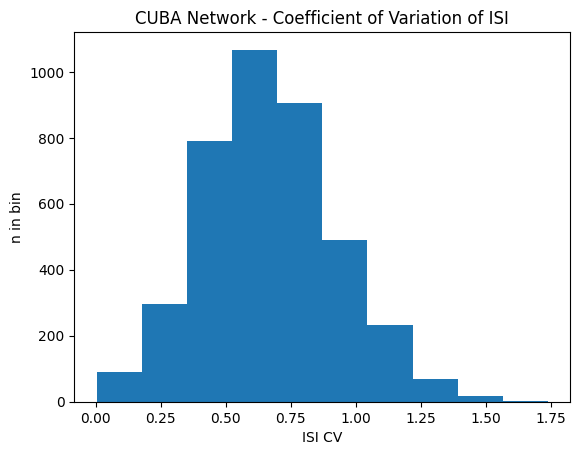

In [13]:
plt.title("CUBA Network - Coefficient of Variation of ISI")
plt.hist(cov_CUBA)
plt.xlabel('ISI CV')
plt.ylabel('n in bin')
plt.show()